# Portfolio Optimization Using Quantum Annealing

## What is Quantum Annealing

Quantum Annealing is quantum optimization technique that tries to find the lowest‑energy solution of a problem by slowly transforming a simple quantum system into one whose ground state encodes the answer. 

It relies on quantum effects (like tunneling) to escape local minima while the system “anneals” toward the global minimum. It’s mainly used for combinatorial optimization and Ising/QUBO formulations.

## How it Works?

For example, in this case of the "valley" of solutions, the goal is to find the lowest valley (best solution).

```
Energy
  ↑
  |        /\        ← bad solutions
  |   /\  /  \
  |  /  \/    \__
  |_/            \___  ← best solution (lowest energy)
  +--------------------→ All possible solutions
```

### Classical Computing

```
Start somewhere
Walk downhill
Might get stuck in local valley

      /\        ← global min
     /  \
 ___/    \__
    ↑ stuck here
```

### Using Quantum Annealing

```
1. Start with a flat / simple landscape (e.g. superposition of all solutions at once),
   ________

2. Landscape forming, where it slowly morph the simple landscape into the real one:

   __/\____

3. State flows downward - as the landscape changes slowly, the quantum system stays in its ground state (lowest energy).

   __/\____
      ↓

4. Ends at global minimum, the Quantum particles can tunnel through hills instead of climbing them, which helps escape local minima.

   __/\____
      ↓↓↓
```

1. Start with the superposition of all solutions: $|\psi\rangle = \sum_x |x\rangle$

2. Introduce the problem landscape: $H(t) = A(t)H_{initial} + B(t)H_{problem}$

3. Quantum state “flows” downward: As the landscape changes slowly, the quantum system stays in its ground state (lowest energy).

4. Quantum tunneling effect: Quantum particles can tunnel through hills instead of climbing them.

In this Use-Case, it the Landscape represents the Risks for the Portfolio Optimization.

In [14]:
! pip3 install qiskit qiskit-finance numpy pandas matplotlib --break-system-packages

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA

#### Step 1: Generate Synthetic Financial Data

Uses `RandomDataProvider` to generate a covariance matrix for 4 assets (AAPL, GOOGL, MSFT, TSLA) over 2022 and computes expected returns. The portfolio problem needs returns and risk (covariances) as inputs.

In [16]:
num_assets = 4

# Define the date range correctly
start = datetime(2022, 1, 1)
end = datetime(2023, 1, 1)

# Initialize Random Data Provider
data_provider = RandomDataProvider(
    tickers=['AAPL', 'GOOGL', 'MSFT', 'TSLA'],
    start=start,
    end=end,
    seed=42
)

data_provider.run()
stock_data = data_provider.get_covariance_matrix()
expected_returns = np.mean(stock_data, axis=0)

# Convert to Pandas DataFrame for visualization
df = pd.DataFrame(stock_data, columns=['AAPL', 'GOOGL', 'MSFT', 'TSLA'])
print("Stock Covariance Matrix:")
print(df)

Stock Covariance Matrix:
        AAPL      GOOGL       MSFT       TSLA
0  32.929644  35.190928  10.995452  26.686611
1  35.190928  75.301763   2.828439  28.476003
2  10.995452   2.828439  20.612460   8.274859
3  26.686611  28.476003   8.274859  32.463091


### Step 2: Define Portfolio Optimization Problem

Sets a risk factor and budget (select 2 assets), builds a `PortfolioOptimization` model, and converts it to a quadratic program. Qiskit’s optimization algorithms operate on quadratic programs/QUBO.

In [17]:
risk_factor = 0.5   # Adjust risk tolerance
budget = 2          # Number of assets to select

# Define Portfolio Optimization
portfolio = PortfolioOptimization(
    expected_returns=expected_returns,
    covariances=stock_data,
    risk_factor=risk_factor,
    budget=budget
)

# Convert to Quadratic Program
quadratic_program = portfolio.to_quadratic_program()
print("\nPortfolio Optimization Problem:")
print(quadratic_program)


Portfolio Optimization Problem:
minimize 16.464822152938986*x_0^2 + 35.19092772257926*x_0*x_1 + 10.995452117508307*x_0*x_2 + 26.68661076715245*x_0*x_3 + 37.650881276848885*x_1^2 + 2.8284390279535705*x_1*x_2 + 28.47600271635904*x_1*x_3 + 10.306230193772645*x_2^2 + 8.27485943694024*x_2*x_3 + 16.231545395904465*x_3^2 - 26.4506587282795*x_0 - 35.44928300514741*x_1 - 10.677802742486852*x_2 - 23.975140928065166*x_3 (4 variables, 1 constraints, 'Portfolio optimization')


#### Step 3: Solve Using SamplingVQE

Defines a variational circuit (TwoLocal), optimizer (COBYLA), and sampler, then solves the quadratic program with MinimumEigenOptimizer using SamplingVQE. This uses a quantum‑inspired variational approach to search for the best portfolio.

In [18]:
# Define Variational Ansatz (Two-Local circuit)
ansatz = TwoLocal(rotation_blocks=["ry", "rz"], entanglement_blocks="cz")

# Define optimizer
optimizer = COBYLA(maxiter=100)

# Initialize the Sampler primitive
sampler = StatevectorSampler()

# Set up SamplingVQE algorithm
sampling_vqe = SamplingVQE(sampler=sampler, ansatz=ansatz, optimizer=optimizer)

# Solve Portfolio Optimization Problem using Minimum Eigen Optimizer
qaoa = MinimumEigenOptimizer(sampling_vqe)
result = qaoa.solve(quadratic_program)

/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_62406/3534782600.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(rotation_blocks=["ry", "rz"], entanglement_blocks="cz")


#### Step 4: Interpret Results

Converts the optimizer result into an asset‑selection vector and prints the chosen tickers. The solution comes out as binary variables, so have to map them back to real asset names.

In [19]:
optimal_portfolio = portfolio.interpret(result)
optimal_portfolio = np.atleast_1d(optimal_portfolio)  # ✅ Ensure 1D array

# Select indices of chosen assets
selected_assets = np.where(optimal_portfolio == 1)[0]
selected_tickers = [df.columns[i] for i in selected_assets]

# Print selected assets
print(f"\nOptimal Portfolio Allocation: {selected_tickers}")


Optimal Portfolio Allocation: []


#### Step 5: Visualize Optimal Portfolio Selection

Text(0.5, 1.0, 'Optimal Portfolio Allocation')

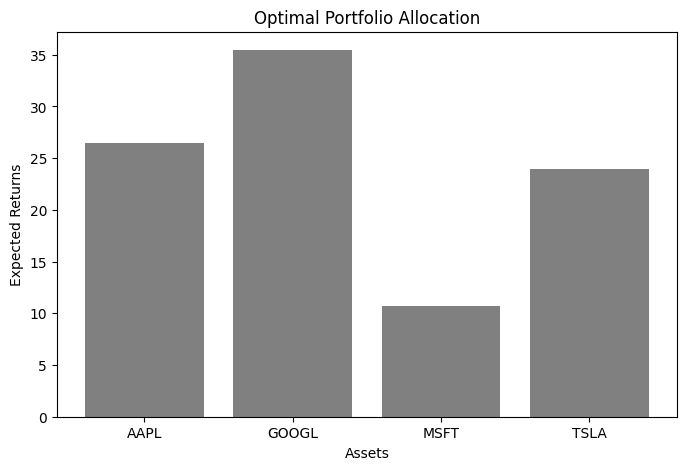

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(
    df.columns,
    expected_returns,
    color=['green' if i in selected_assets else 'gray' for i in range(len(df.columns))]
)
plt.xlabel("Assets")
plt.ylabel("Expected Returns")
plt.title("Optimal Portfolio Allocation")